## Cell 1 — Install Dependencies

In [2]:
!pip install osmnx==1.9.3 geopandas folium

## Cell 2 — Imports

In [3]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
from shapely.ops import unary_union
import warnings
warnings.filterwarnings('ignore')

print('OSMnx version:', ox.__version__)  # should be 1.9.3

OSMnx version: 1.9.3


## Cell 3 — Load GeoJSON



In [4]:
poi = gpd.read_file('mumbai_lamps_police.geojson')

print('POI count:', len(poi))
print('Columns:', poi.columns.tolist())
print('highway values:', poi['highway'].unique() if 'highway' in poi.columns else 'N/A')
print('amenity values:', poi['amenity'].unique() if 'amenity' in poi.columns else 'N/A')

poi.head()

POI count: 728
Columns: ['id', '@id', 'addr:city', 'addr:housenumber', 'addr:postcode', 'addr:street', 'amenity', 'check_date', 'description', 'direction', 'ele', 'height', 'highway', 'lamp_mount', 'lamp_type', 'light:count', 'light:direction', 'loc_name', 'name', 'name:en', 'name:hi', 'name:mr', 'nat_name', 'official_name', 'opening_hours', 'operator', 'operator:wikidata', 'phone', 'postal_code', 'ref', 'reg_name', 'short_name', 'source', 'support', 'sym', 'wheelchair', 'wpt_symbol', 'geometry']
highway values: [None 'street_lamp']
amenity values: ['police' None]


,id,@id,addr:city,addr:housenumber,addr:postcode,addr:street,amenity,check_date,description,direction,...,postal_code,ref,reg_name,short_name,source,support,sym,wheelchair,wpt_symbol,geometry
0,node/347152618,node/347152618,None,None,None,None,police,NaT,None,None,...,None,None,None,None,None,None,None,None,None,POINT (72.83711 19.06404)
1,node/605221901,node/605221901,None,None,None,None,police,NaT,None,None,...,None,None,None,None,None,None,None,None,None,POINT (72.83033 18.94537)
2,node/858544370,node/858544370,None,None,None,None,police,NaT,None,None,...,None,None,None,None,None,None,None,None,None,POINT (72.8291 18.95693)
3,node/858544419,node/858544419,None,None,None,None,police,NaT,None,None,...,None,None,None,None,None,None,None,None,None,POINT (72.83202 18.95417)
4,node/860348747,node/860348747,None,None,None,None,police,NaT,None,None,...,400009,None,None,None,None,None,None,None,None,POINT (72.83905 18.96214)


## Cell 4 — Bounding Box & Road Graph




In [5]:
minx, miny, maxx, maxy = poi.total_bounds
BUFFER = 0.01  # degrees

G = ox.graph_from_bbox(
    bbox=(maxy + BUFFER, miny - BUFFER, maxx + BUFFER, minx - BUFFER),
    network_type='drive'
)

edges = ox.graph_to_gdfs(G, nodes=False, fill_edge_geometry=True).reset_index()
edges['segment_id'] = edges.index
roads = edges[['segment_id', 'u', 'v', 'key', 'geometry', 'highway', 'length']].copy()

print(f'Road segments: {len(roads)}')
roads.head()

Road segments: 108723


,segment_id,u,v,key,geometry,highway,length
0,0,30610511,12558690624,0,"LINESTRING (73.09612 19.19251, 73.09576 19.19201)",primary,66.698
1,1,30610511,1541914126,0,"LINESTRING (73.09612 19.19251, 73.09604 19.19255)",unclassified,9.253
2,2,30610544,3508501446,0,"LINESTRING (73.08294 19.17221, 73.083 19.17217)",primary,8.002
3,3,30610544,1827513712,0,"LINESTRING (73.08294 19.17221, 73.08365 19.172...",primary,655.059
4,4,30610591,5227697818,0,"LINESTRING (73.04671 19.14294, 73.0461 19.1421...",tertiary,1210.208


In [6]:
# ── Cell 4b: Intersection Density ────────────────────────────
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
node_degree = dict(G.degree())

def avg_endpoint_degree(row):
    return (node_degree.get(row["u"], 1) + node_degree.get(row["v"], 1)) / 2

edges["intersection_density"] = edges.apply(avg_endpoint_degree, axis=1)
roads["intersection_density"] = edges["intersection_density"].values

print("Intersection density stats:")
print(roads["intersection_density"].describe())

Intersection density stats:
count    108723.000000
mean          5.260672
std           1.198708
min           1.500000
25%           4.000000
50%           6.000000
75%           6.000000
max           9.000000
Name: intersection_density, dtype: float64


## Cell 5 — Project to UTM
converting degrees to meters.

In [7]:
UTM = 32643

roads  = roads.set_crs(4326).to_crs(UTM)
lamps  = poi[poi['highway'] == 'street_lamp'].copy().set_crs(4326).to_crs(UTM)
police = poi[poi['amenity'] == 'police'].copy().set_crs(4326).to_crs(UTM)

print(f'Lamps:  {len(lamps)}')
print(f'Police: {len(police)}')

Lamps:  652
Police: 76


## Cell 6 — Feature 1: Lighting Score
Counts street lamps within 50 m of each road segment



In [8]:
LAMP_BUFFER = 50  # metres

road_buf = roads[['segment_id', 'geometry']].copy()
road_buf['geometry'] = road_buf.geometry.buffer(LAMP_BUFFER)

joined = gpd.sjoin(road_buf, lamps[['geometry']], how='left', predicate='contains')
lamp_counts = joined[joined['index_right'].notna()].groupby('segment_id').size()

roads['lamp_count'] = roads['segment_id'].map(lamp_counts).fillna(0).astype(int)

road_light = {
    'motorway': 3, 'trunk': 3, 'primary': 3,
    'secondary': 2, 'tertiary': 2,
    'residential': 1, 'unclassified': 1,
    'service': 0, 'footway': 0, 'path': 0,
}
roads['road_type_light'] = (
    roads['highway']
    .apply(lambda x: x[0] if isinstance(x, list) else x)
    .map(road_light)
    .fillna(1)
)


roads["lighting_raw"] = roads["road_type_light"]

print('Lamp count distribution:')
print(roads['lamp_count'].describe())
print('\nRoads with at least 1 lamp:', (roads['lamp_count'] > 0).sum())

Lamp count distribution:
count    108723.000000
mean          0.015820
std           2.313194
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         540.000000
Name: lamp_count, dtype: float64

Roads with at least 1 lamp: 187


## Cell 7 — Feature 2: Police Proximity
Distance from each road segment to its nearest police station.

In [9]:
if len(police) > 0:
    police_sindex = police.sindex

    def dist_to_nearest_police(geom):
        candidates = list(police_sindex.nearest(geom, 1))
        return geom.distance(police.iloc[candidates[0]].geometry)

    roads['dist_police'] = roads.geometry.apply(dist_to_nearest_police)
else:
    # Fallback: no police data → neutral distance
    roads['dist_police'] = roads.geometry.length.mean() * 5
    print('WARNING: No police stations found in GeoJSON — using neutral fallback')

print('Police distance stats (metres):')
print(roads['dist_police'].describe())

Police distance stats (metres):
count    108723.000000
mean      15473.659065
std        8264.267219
min           9.286691
25%        8025.676138
50%       16025.643068
75%       21737.218189
max       33992.443972
Name: dist_police, dtype: float64


## Cell 8 — Feature 3: Activity / Crowd Density
Fetches amenities, shops, and leisure POIs from OSM as a crowd proxy.
More POIs nearby = more people around = moderate safety benefit.


In [10]:
activity_tags = {'amenity': True, 'shop': True, 'leisure': True}

activity = ox.features_from_bbox(
    bbox=(maxy + BUFFER, miny - BUFFER, maxx + BUFFER, minx - BUFFER),
    tags=activity_tags
)
activity = activity[activity.geometry.type == 'Point'].to_crs(UTM)
print(f'Activity POIs fetched: {len(activity)}')

road_buf2 = roads[['segment_id', 'geometry']].copy()
road_buf2['geometry'] = road_buf2.geometry.buffer(LAMP_BUFFER)

joined_act = gpd.sjoin(
    activity[['geometry']], road_buf2, how='inner', predicate='intersects'
)
act_counts = joined_act.groupby('segment_id').size()

roads['activity_count'] = roads['segment_id'].map(act_counts).fillna(0)

print('Activity count stats:')
print(roads['activity_count'].describe())

Activity POIs fetched: 11353
Activity count stats:
count    108723.000000
mean          0.667283
std           2.433838
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         122.000000
Name: activity_count, dtype: float64


## Cell 9 — Feature 4: Risk Source Proximity
Bars, nightclubs, industrial zones = elevated risk. We measure distance from each
road segment to the nearest such location. **Closer = more dangerous.**

Risk sources used:
- Bars, pubs, nightclubs
- Industrial / construction land use

In [11]:
risk_tags = {
    "amenity": ["bar", "pub", "nightclub", "atm", "bank"],
    "landuse": ["industrial", "construction", "warehouse"],
    "highway": ["bus_stop"],
    "railway": ["station", "subway_entrance"],
}

risk_pois = ox.features_from_bbox(
    bbox=(maxy + BUFFER, miny - BUFFER, maxx + BUFFER, minx - BUFFER),
    tags=risk_tags
)
risk_pois = risk_pois.to_crs(UTM)
risk_pois['geometry'] = risk_pois.geometry.centroid  # now in UTM, correct

print(f'Risk POIs: {len(risk_pois)}')

if len(risk_pois) > 0:
    risk_union = unary_union(risk_pois.geometry)
    roads['dist_risk'] = roads.geometry.apply(lambda g: g.distance(risk_union))
else:
    roads['dist_risk'] = 9999.0
    print('WARNING: No risk POIs found — dist_risk set to 9999 (max safe)')

print('Risk distance stats (metres):')
print(roads['dist_risk'].describe())

Risk POIs: 5737
Risk distance stats (metres):
count    108723.000000
mean        195.604894
std         192.176913
min           0.000000
25%          67.807311
50%         147.328077
75%         264.061903
max        3827.712759
Name: dist_risk, dtype: float64


## Cell 10 — Normalize Features to [0, 1]



In [12]:
def minmax(series):
    lo, hi = series.min(), series.max()
    if hi == lo:
        return pd.Series(0.5, index=series.index)  # flat → neutral
    return (series - lo) / (hi - lo)

# Lighting: more lamps = safer
roads['f_lighting'] = minmax(roads['lighting_raw'])

# Police: closer = safer → invert distance
roads['f_police'] = 1 - minmax(roads['dist_police'])

# Instead of minmax on raw counts:
roads['f_activity'] = np.log1p(roads['activity_count'])
roads['f_activity'] = roads['f_activity'] / roads['f_activity'].max()

roads["f_intersection"] = minmax(roads["intersection_density"])

# Risk: closer to risk sources = worse → invert, cap at 200 m
dist_risk_capped = roads['dist_risk'].clip(upper=200)
roads['f_risk'] = minmax(dist_risk_capped)  # high value = far from risk = good



print('Feature distributions — std dev should be > 0.05 for meaningful routing:')
print('-' * 60)
for col in ['f_lighting', 'f_police', 'f_activity', 'f_risk','f_intersection']:
    s = roads[col]
    print(f'{col:15s}  min={s.min():.3f}  mean={s.mean():.3f}  max={s.max():.3f}  std={s.std():.3f}')

Feature distributions — std dev should be > 0.05 for meaningful routing:
------------------------------------------------------------
f_lighting       min=0.000  mean=0.162  max=1.000  std=0.281
f_police         min=0.000  mean=0.545  max=1.000  std=0.243
f_activity       min=0.000  mean=0.057  max=1.000  std=0.112
f_risk           min=0.000  mean=0.656  max=1.000  std=0.345
f_intersection   min=0.000  mean=0.501  max=1.000  std=0.160


## Cell 11 — Compute Safety Score
Weighted sum of the four normalized features. Weights reflect importance for women's safety:


Safety score distribution:
count    108723.000000
mean          0.372639
std           0.110393
min           0.065558
25%           0.300258
50%           0.368630
75%           0.439968
max           0.828636
Name: safety_score, dtype: float64

Std dev: 0.1104  ← should be > 0.05


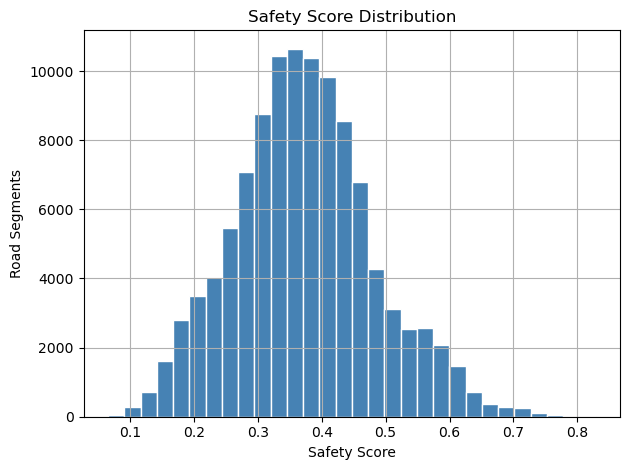

In [13]:

W_LIGHT        = 0.30
W_POLICE       = 0.20
W_ACTIVITY     = 0.15
W_RISK         = 0.20
W_INTERSECTION = 0.15

roads["safety_score"] = (
    W_LIGHT        * roads["f_lighting"]      +
    W_POLICE       * roads["f_police"]        +
    W_ACTIVITY     * roads["f_activity"]      +
    W_RISK         * roads["f_risk"]          +
    W_INTERSECTION * roads["f_intersection"]
).clip(0, 1)

print('Safety score distribution:')
print(roads['safety_score'].describe())
print(f"\nStd dev: {roads['safety_score'].std():.4f}  ← should be > 0.05")

# Quick histogram
roads['safety_score'].hist(bins=30, color='steelblue', edgecolor='white')
import matplotlib.pyplot as plt
plt.title('Safety Score Distribution')
plt.xlabel('Safety Score')
plt.ylabel('Road Segments')
plt.tight_layout()
plt.show()

## Cell 12 — Push Safety Scores Into the Graph
Assigns `safety_score` and `safe_cost` to every edge in the NetworkX graph.

```
safe_cost = length / safety_score
```

This means: a 100 m road with safety=0.1 costs **10×** more than a 100 m road with safety=1.0.
The router will strongly prefer safer roads, even if they're a bit longer.

In [14]:
score_map = dict(zip(roads['segment_id'], roads['safety_score']))

edges_indexed = edges.copy()
edges_indexed['safety_score'] = edges_indexed['segment_id'].map(score_map).fillna(0.5)

for _, row in edges_indexed.iterrows():
    u, v, k = row['u'], row['v'], row['key']
    if v in G[u] and k in G[u][v]:
        G[u][v][k]['safety_score'] = row['safety_score']

# safe_cost: min safety floor = 0.05 to avoid division by near-zero
for u, v, k, data in G.edges(keys=True, data=True):
    s = max(data.get('safety_score', 0.5), 0.05)
    data['safe_cost'] = data['length'] / s

print('Safety scores and safe_cost assigned to all edges ✓')

Safety scores and safe_cost assigned to all edges ✓


## Cell 13 — Route & Compare
Computes the **shortest** route (by distance) and the **safest** route (by safe_cost).
Then prints stats so you can verify they are actually different.



In [20]:
# ── REPLACE THESE WITH YOUR OWN COORDINATES ────────────────────────────────
lat1, lon1 = 19.0228, 72.8551   # VJTI College
lat2, lon2 = 18.9398, 72.8354   # CST / Chhatrapati Shivaji Terminus
# ─────────────────────────────────────────────────────────────────────────────

orig = ox.distance.nearest_nodes(G, X=lon1, Y=lat1)
dest = ox.distance.nearest_nodes(G, X=lon2, Y=lat2)

shortest_route = nx.shortest_path(G, orig, dest, weight='length')
safest_route   = nx.shortest_path(G, orig, dest, weight='safe_cost')

def route_stats(G, route, label):
    edges_in = list(zip(route[:-1], route[1:]))
    lengths, scores = [], []
    for u, v in edges_in:
        k = list(G[u][v].keys())[0]
        data = G[u][v][k]
        lengths.append(data.get('length', 0))
        scores.append(data.get('safety_score', 0.5))
    total_len = sum(lengths)
    print(f'\n{label}')
    print(f'  Nodes         : {len(route)}')
    print(f'  Total length  : {total_len:.0f} m  ({total_len/1000:.2f} km)')
    print(f'  Avg safety    : {np.mean(scores):.4f}')
    print(f'  Min safety    : {min(scores):.4f}')
    return np.mean(scores)

s1 = route_stats(G, shortest_route, 'SHORTEST ROUTE')
s2 = route_stats(G, safest_route,   'SAFEST ROUTE')

print(f'\nSafety improvement: {((s2 - s1) / s1 * 100):+.1f}%')
print(f"Routes are: {'IDENTICAL ← problem still exists' if shortest_route == safest_route else 'DIFFERENT ✓'}")


SHORTEST ROUTE
  Nodes         : 95
  Total length  : 10223 m  (10.22 km)
  Avg safety    : 0.5384
  Min safety    : 0.3921

SAFEST ROUTE
  Nodes         : 80
  Total length  : 10981 m  (10.98 km)
  Avg safety    : 0.5857
  Min safety    : 0.3240

Safety improvement: +8.8%
Routes are: DIFFERENT ✓


## Cell 14 — Interactive Map
Renders both routes on a dark map using Folium.
- 🔴 Red = shortest route
- 🟢 Green = safest route

In [ ]:
import folium

mid_lat = (lat1 + lat2) / 2
mid_lon = (lon1 + lon2) / 2

m = folium.Map(
    location=[mid_lat, mid_lon],
    zoom_start=13,
    tiles='CartoDB dark_matter'
)

def route_to_coords(G, route):
    return [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

folium.PolyLine(
    route_to_coords(G, shortest_route),
    color='red', weight=5, opacity=0.85,
    tooltip='Shortest Route'
).add_to(m)

folium.PolyLine(
    route_to_coords(G, safest_route),
    color='lime', weight=5, opacity=0.85,
    tooltip='Safest Route'
).add_to(m)

folium.Marker(
    [lat1, lon1], tooltip='Start',
    icon=folium.Icon(color='blue', icon='play')
).add_to(m)
folium.Marker(
    [lat2, lon2], tooltip='End',
    icon=folium.Icon(color='purple', icon='stop')
).add_to(m)

# Display inline in Colab
from IPython.display import display
display(m)

m.save('safe_route_map.html')
print('Map also saved → safe_route_map.html')

Map also saved → safe_route_map.html


: 

## Cell 15 — Export Dataset
Saves all road segments with their raw and normalized features + final safety score.
Use this CSV for further ML experiments (e.g. training a model on labelled crime data later).

In [17]:
final = roads[[
    'segment_id',
    'safety_score',
    'lamp_count',
    'road_type_light',
    'lighting_raw',
    'dist_police',
    'activity_count',
    'dist_risk',
    'f_lighting',
    'f_police',
    'f_activity',
    'f_risk',
]].copy()

final.to_csv('safe_route_dataset.csv', index=False)
print('Dataset saved → safe_route_dataset.csv')
print(f'Shape: {final.shape}')
final.describe()

Dataset saved → safe_route_dataset.csv
Shape: (108723, 12)


,segment_id,safety_score,lamp_count,road_type_light,lighting_raw,dist_police,activity_count,dist_risk,f_lighting,f_police,f_activity,f_risk
count,108723.000000,108723.000000,108723.000000,108723.000000,108723.000000,108723.000000,108723.000000,108723.000000,108723.000000,108723.000000,108723.000000,108723.000000
mean,54361.000000,0.372639,0.015820,1.324559,1.324559,15473.659065,0.667283,195.604894,0.162279,0.544940,0.056657,0.656279
std,31385.770996,0.110393,2.313194,0.562385,0.562385,8264.267219,2.433838,192.176913,0.281193,0.243187,0.112297,0.345269
min,0.000000,0.065558,0.000000,1.000000,1.000000,9.286691,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27180.500000,0.300258,0.000000,1.000000,1.000000,8025.676138,0.000000,67.807311,0.000000,0.360626,0.000000,0.339037
50%,54361.000000,0.368630,0.000000,1.000000,1.000000,16025.643068,0.000000,147.328077,0.000000,0.528697,0.000000,0.736640
75%,81541.500000,0.439968,0.000000,2.000000,2.000000,21737.218189,1.000000,264.061903,0.500000,0.764107,0.144040,1.000000
max,108722.000000,0.828636,540.000000,3.000000,3.000000,33992.443972,122.000000,3827.712759,1.000000,1.000000,1.000000,1.000000
